# Portfolio Project: King County House Price Modeling

This notebook documents an end-to-end regression workflow on residential sales data from King County, WA. The focus is practical model building: data quality checks, feature exploration, baseline models, and regularized refinements.

## Roadmap

1. Data ingestion and schema validation
2. Data wrangling and missing-value handling
3. Exploratory analysis and signal checks
4. Baseline linear models
5. Evaluation and refinement with regularization

## Project Context

Goal: estimate house sale price from structural, location, and quality features.

Approach: start with lightweight inspection and cleaning, then move through EDA into progressively stronger regression baselines.

## Dataset Snapshot

This dataset contains residential home sales in King County (Seattle region), covering transactions between May 2014 and May 2015. Source data was adapted from Kaggle for educational use.

| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | A notation for a house                                                                                      |
| date          | Date house was sold                                                                                         |
| price         | Price is prediction target                                                                                  |
| bedrooms      | Number of bedrooms                                                                                          |
| bathrooms     | Number of bathrooms                                                                                         |
| sqft_living   | Square footage of the home                                                                                  |
| sqft_lot      | Square footage of the lot                                                                                   |
| floors        | Total floors (levels) in house                                                                              |
| waterfront    | House which has a view to a waterfront                                                                      |
| view          | Has been viewed                                                                                             |
| condition     | How good the condition is overall                                                                           |
| grade         | overall grade given to the housing unit, based on King County grading system                                |
| sqft_above    | Square footage of house apart from basement                                                                 |
| sqft_basement | Square footage of the basement                                                                              |
| yr_built      | Built Year                                                                                                  |
| yr_renovated  | Year when house was renovated                                                                               |
| zipcode       | Zip code                                                                                                    |
| lat           | Latitude coordinate                                                                                         |
| long          | Longitude coordinate                                                                                        |
| sqft_living15 | Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area |
| sqft_lot15    | LotSize area in 2015(implies-- some renovations)                                                            |


## Environment Setup

In [55]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

In [56]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [57]:
#!pip install -U scikit-learn

In [58]:
import piplite
await piplite.install('seaborn')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
%matplotlib inline

# Phase 1: Data Ingestion

Fetch the dataset and persist it locally for repeatable runs.

In [59]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

In [60]:
filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'

In [61]:
await download(filepath, "housing.csv")
file_name="housing.csv"

Load the CSV into a pandas DataFrame.

In [62]:
df = pd.read_csv(file_name)

Environment note: in browser-based JupyterLite, the file is downloaded first and then loaded from local storage. In a local Python environment, the source URL can be passed directly to `pd.read_csv`.

In [63]:
#filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
#df = pd.read_csv(filepath, header=None)

Quick sanity check: inspect the first few rows.

In [64]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Checkpoint 1: Schema audit

Review column data types before feature selection and modeling.

In [ ]:
# Checkpoint 1: inspect inferred dtypes
df.dtypes

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Generate a statistical summary to understand ranges, central tendency, and potential outliers.

In [66]:
df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# Phase 2: Data Quality and Wrangling

### Checkpoint 2: Drop non-model fields and re-profile

Remove identifier-only columns (`id`, `Unnamed: 0`) and regenerate summary stats.

In [ ]:
# Checkpoint 2: drop non-model columns and re-profile
df.drop(columns=['id', 'Unnamed: 0'], inplace=True)
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Missing values are present in `bedrooms` and `bathrooms`; quantify impact before imputation.

In [68]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())


number of NaN values for the column bedrooms : 13
number of NaN values for the column bathrooms : 10


Impute missing `bedrooms` values with the column mean as a baseline strategy.

In [69]:
mean=df['bedrooms'].mean()
df['bedrooms'].replace(np.nan,mean, inplace=True)

Apply the same mean-imputation baseline to missing `bathrooms` values.

In [70]:
mean=df['bathrooms'].mean()
df['bathrooms'].replace(np.nan,mean, inplace=True)

In [71]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


# Phase 3: Exploratory Analysis

### Checkpoint 3: Floor-level distribution

Quantify listing counts by floor count to understand housing inventory shape.

In [ ]:
# Checkpoint 3: floor-count distribution
df['floors'].to_frame().value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


### Checkpoint 4: Waterfront vs. price spread

Use a boxplot to compare price distribution and outlier behavior by waterfront flag.

(0.0, 8081250.0)

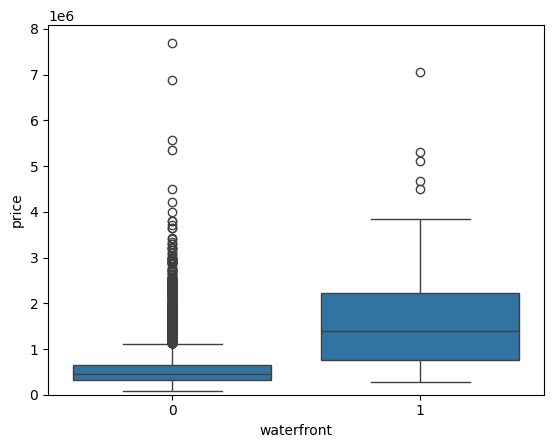

In [74]:
sns.boxplot(df, x='waterfront', y='price')
plt.ylim(0,)

### Checkpoint 5: `sqft_above` signal check

Use a regression plot to validate direction and strength of association with target price.

(0.0, 8081250.0)

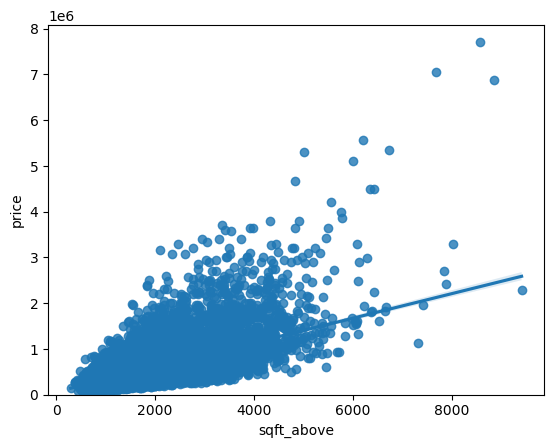

In [ ]:
# Checkpoint 5: sqft_above vs price trend
sns.regplot(df, x='sqft_above', y='price')
plt.ylim(0,)

Compute full numeric correlation against `price` to identify high-signal candidate features.

In [77]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values()

zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308797
sqft_basement    0.323816
view             0.397293
bathrooms        0.525738
sqft_living15    0.585379
sqft_above       0.605567
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

# Phase 4: Baseline Modeling

Start with a single-feature linear baseline using longitude (`long`) and record in-sample $R^2$.

In [78]:
X = df[['long']]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
lm.score(X, Y)

0.00046769430149007363

### Checkpoint 6: Single-feature baseline (`sqft_living`)

Train linear regression on `sqft_living` and log in-sample $R^2$.

In [ ]:
# Checkpoint 6: single-feature linear baseline
lm_sqft_living = LinearRegression()
X=df[['sqft_living']]
Y=df['price']
lm_sqft_living.fit(X, Y)
lm_sqft_living.score(X, Y)

0.4928532179037931

### Checkpoint 7: Multi-feature linear baseline

Fit linear regression using a curated feature list and compare $R^2$ to prior baselines.

In [ ]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]

Evaluate in-sample $R^2$ for the multi-feature linear model.

In [ ]:
# Checkpoint 7: multi-feature linear baseline
X=df[features]
Y=df['price']
lm=LinearRegression()
lm.fit(X, Y)
lm.score(X, Y)

0.6576890354915759

Pipeline components for nonlinear expansion + scaling + linear estimation:

- `StandardScaler()`
- `PolynomialFeatures(include_bias=False)`
- `LinearRegression()`

In [92]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]

### Checkpoint 8: Polynomial pipeline baseline

Build the pipeline from the components above, fit on the selected features, and record $R^2$.

In [ ]:
# Checkpoint 8: polynomial pipeline baseline
from sklearn.metrics import r2_score
pipe = Pipeline(Input)
pipe.fit(X, Y)
r2_score(pipe.predict(X), Y)

0.669013185349802

# Phase 5: Evaluation and Refinement

Import evaluation and splitting utilities for holdout testing.

In [95]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
print("done")

done


Create train/test splits to separate fitting from performance validation.

In [ ]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


### Checkpoint 9: Ridge regression on holdout

Fit Ridge with `alpha=0.1` on training data and evaluate test-set $R^2$.

In [97]:
from sklearn.linear_model import Ridge

In [ ]:
# Checkpoint 9: Ridge on holdout split
ridge = Ridge(alpha=0.1)
ridge.fit(x_train, y_train)
ridge.score(x_test, y_test)

0.647875916393907

### Checkpoint 10: Polynomial features + Ridge

Apply a second-order polynomial transform, retrain Ridge (`alpha=0.1`), and compare test-set $R^2$ against the linear Ridge baseline.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

ridge_poly = Ridge(alpha=0.1)
ridge_poly.fit(x_train_poly, y_train)
ridge_poly.score(x_test_poly, y_test)

## Wrap-up

This notebook captures a practical progression from raw data ingestion to regularized nonlinear regression, with each checkpoint recording model behavior and trade-offs.

## Source Attribution

Original exercise structure adapted from IBM Skills Network material; content and narrative rewritten for portfolio presentation.

Dataset: King County House Sales (Kaggle-derived educational variant).

Notebook revision: converted assignment-style prompts into engineering checkpoints for portfolio use.